In [1]:
# https://www.youtube.com/watch?v=CbTU92pbDKw

In [2]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-21,315.589996,0.0,315.589996,0.0,316.410004,313.950012,315.019989,0.0,20372300
2025-04-22,311.109985,0.0,311.109985,0.0,317.630005,310.359985,317.489990,0.0,35242300


In [3]:
finbert_score = pd.read_csv("../Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score["sentiment"] = finbert_score["Positive"] - finbert_score["Negative"]

In [4]:
cluster_data = pd.read_csv("../cluster_embedding_output.csv")
cluster_data.head()

,Dates,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
0,2000-02-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-02-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2000-03-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2000-04-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2000-05-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
finbert_score

,Date,Positive,Neutral,Negative,sentiment
0,2000-02-15,0.398276,0.585515,0.016209,0.382066
1,2000-02-17,0.077722,0.095735,0.826543,-0.748821
2,2000-03-24,0.180700,0.287722,0.531578,-0.350879
3,2000-04-27,0.393267,0.346374,0.260358,0.132909
4,2000-05-04,0.337279,0.255016,0.407705,-0.070426
...,...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982,0.693664
3668,2019-01-28,0.749922,0.169181,0.080897,0.669025
3669,2019-01-30,0.790114,0.135270,0.074616,0.715498
3670,2019-01-31,0.128171,0.481111,0.390717,-0.262546


In [6]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])
cluster_data["Date"] = pd.to_datetime(cluster_data["Dates"])

In [7]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [8]:
merged_df = pd.merge(finbert_score, gold_data, on="Date", how="inner")
merged_df = pd.merge(
    merged_df, cluster_data, left_on="Date", right_on="Date", how="inner"
)

In [9]:
merged_df.columns

Index(['Date', 'Positive', 'Neutral', 'Negative', 'sentiment', 'Adj Close',
       'Capital Gains', 'Close', 'Dividends', 'High', 'Low', 'Open',
       'Stock Splits', 'Volume', 'Dates', 'topic_china_fed_and_gold_focus',
       'topic_comex_gold_closing_prices', 'topic_early_gold_trading_activity',
       'topic_economic_data_and_gold_performance',
       'topic_global_cues_and_gold_stability',
       'topic_global_investment_and_rate_impact',
       'topic_gold_climbs_in_trading', 'topic_gold_holds_as_data_releases',
       'topic_gold_market_turning_points', 'topic_gold_near_monthly_lows',
       'topic_gold_price_support_levels', 'topic_gold_prices_and_metal_shares',
       'topic_gold_settlement_price_correction',
       'topic_gold_spot_price_outlook',
       'topic_gold_trading_momentum_continues',
       'topic_market_rates_and_gold_demand',
       'topic_rate_hikes/cuts_price_impact', 'topic_time_sensitive_prediction',
       'topic_noise'],
      dtype='object')

In [10]:
df = merged_df[
    [
        "Date",
        "sentiment",
        "Open",
        "topic_china_fed_and_gold_focus",
        "topic_comex_gold_closing_prices",
        "topic_early_gold_trading_activity",
        "topic_economic_data_and_gold_performance",
        "topic_global_cues_and_gold_stability",
        "topic_global_investment_and_rate_impact",
        "topic_gold_climbs_in_trading",
        "topic_gold_holds_as_data_releases",
        "topic_gold_market_turning_points",
        "topic_gold_near_monthly_lows",
        "topic_gold_price_support_levels",
        "topic_gold_prices_and_metal_shares",
        "topic_gold_settlement_price_correction",
        "topic_gold_spot_price_outlook",
        "topic_gold_trading_momentum_continues",
        "topic_market_rates_and_gold_demand",
        "topic_rate_hikes/cuts_price_impact",
        "topic_time_sensitive_prediction",
        "topic_noise",
    ]
]

df

,Date,sentiment,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,...,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
0,2004-11-18,-0.579322,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,2004-11-19,0.726477,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2004-11-22,0.347871,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2004-11-23,-0.801077,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2004-11-24,0.892562,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2019-01-25,0.693664,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2915,2019-01-28,0.669025,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2916,2019-01-30,0.715498,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2917,2019-01-31,-0.262546,125.180000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [11]:
# make date the index
df.index = df.pop("Date")
df

,sentiment,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,...,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,-0.579322,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2004-11-19,0.726477,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-22,0.347871,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2004-11-23,-0.801077,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-24,0.892562,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-25,0.693664,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-28,0.669025,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-30,0.715498,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


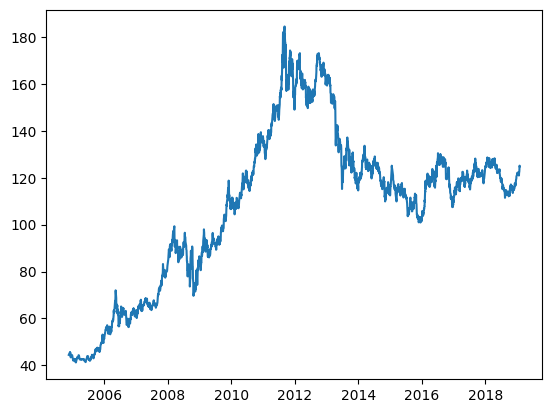

In [12]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Open"])

In [13]:
import numpy as np


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[
            [
                "Open",
                "sentiment",
                "topic_china_fed_and_gold_focus",
                "topic_comex_gold_closing_prices",
                "topic_early_gold_trading_activity",
                "topic_economic_data_and_gold_performance",
                "topic_global_cues_and_gold_stability",
                "topic_global_investment_and_rate_impact",
                "topic_gold_climbs_in_trading",
                "topic_gold_holds_as_data_releases",
                "topic_gold_market_turning_points",
                "topic_gold_near_monthly_lows",
                "topic_gold_price_support_levels",
                "topic_gold_prices_and_metal_shares",
                "topic_gold_settlement_price_correction",
                "topic_gold_spot_price_outlook",
                "topic_gold_trading_momentum_continues",
                "topic_market_rates_and_gold_demand",
                "topic_rate_hikes/cuts_price_impact",
                "topic_time_sensitive_prediction",
                "topic_noise",
            ]
        ].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x)
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = list(
            X[:, i]
        )  # each element is a pair: [Close, sentiment]

    ret_df["Target"] = Y

    return ret_df

In [14]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,"[44.43000030517578, -0.5793219208717346, 0.0, ...","[44.4900016784668, 0.7264769300818444, 0.0, 0....","[44.75, 0.3478713557124139, 0.0, 0.0, 0.0, 0.0...",44.880001
1,2004-11-24,"[44.4900016784668, 0.7264769300818444, 0.0, 0....","[44.75, 0.3478713557124139, 0.0, 0.0, 0.0, 0.0...","[44.880001068115234, -0.8010769858956337, 0.0,...",44.930000
2,2004-11-29,"[44.75, 0.3478713557124139, 0.0, 0.0, 0.0, 0.0...","[44.880001068115234, -0.8010769858956337, 0.0,...","[44.93000030517578, 0.8925615362823012, 0.0, 1...",45.099998
3,2004-11-30,"[44.880001068115234, -0.8010769858956337, 0.0,...","[44.93000030517578, 0.8925615362823012, 0.0, 1...","[45.099998474121094, 0.0849677324295044, 0.0, ...",45.369999
4,2004-12-01,"[44.93000030517578, 0.8925615362823012, 0.0, 1...","[45.099998474121094, 0.0849677324295044, 0.0, ...","[45.369998931884766, -0.8006784543395044, 0.0,...",45.279999
...,...,...,...,...,...
2911,2019-01-25,"[122.27999877929688, 0.8107122350484133, 0.0, ...","[120.95999908447266, 0.8944073989987373, 0.0, ...","[121.16000366210938, -0.6877921521663666, 0.0,...",122.019997
2912,2019-01-28,"[120.95999908447266, 0.8944073989987373, 0.0, ...","[121.16000366210938, -0.6877921521663666, 0.0,...","[122.0199966430664, 0.6936637610197068, 0.0, 0...",122.750000
2913,2019-01-30,"[121.16000366210938, -0.6877921521663666, 0.0,...","[122.0199966430664, 0.6936637610197068, 0.0, 0...","[122.75, 0.6690251007676125, 0.0, 0.0, 0.0, 0....",123.910004
2914,2019-01-31,"[122.0199966430664, 0.6936637610197068, 0.0, 0...","[122.75, 0.6690251007676125, 0.0, 0.0, 0.0, 0....","[123.91000366210938, 0.7154975235462189, 0.0, ...",125.180000


In [15]:
df

,sentiment,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,...,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,-0.579322,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2004-11-19,0.726477,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-22,0.347871,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2004-11-23,-0.801077,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-24,0.892562,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-25,0.693664,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-28,0.669025,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-30,0.715498,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
def windowed_df_to_date_X_y(windowed_dataframe):
    dates = windowed_dataframe["Target Date"].to_numpy()

    feature_cols = windowed_dataframe.columns[1:-1]

    X = []
    for _, row in windowed_dataframe[feature_cols].iterrows():
        # Each val is a [Close, Sentiment] pair
        values = [val for val in row]  # Keep as 2D structure
        X.append(values)

    X = np.array(X)  # Shape will be (num_rows, n, 2)
    Y = windowed_dataframe["Target"].to_numpy()

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((2916,), (2916, 3, 21), (2916,))

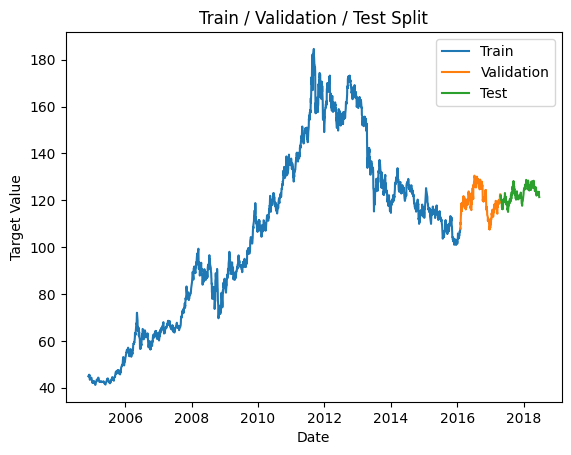

In [ ]:
# training part
q_75 = int(len(dates) * 0.75)

# validation part
q_85 = int(len(dates) * 0.85)

# testing part
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_75], X[:q_75], y[:q_75]
dates_val, X_val, y_val = dates[q_75:q_85], X[q_75:q_85], y[q_75:q_85]
dates_test, X_test, y_test = dates[q_85:q_95], X[q_85:q_95], y[q_85:q_95]
dates_hold, X_hold, y_hold = dates[q_95:], X[q_95:], y[q_95:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.title("Train / Validation / Test Split")
plt.show()

In [18]:
X_train

array([[[ 44.43      ,  -0.5793219 ,   0.        , ...,   0.        ,
           0.        ,   2.        ],
        [ 44.49      ,   0.7264769 ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [ 44.75      ,   0.34787136,   0.        , ...,   0.        ,
           0.        ,   1.        ]],

       [[ 44.49      ,   0.7264769 ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [ 44.75      ,   0.34787136,   0.        , ...,   0.        ,
           0.        ,   1.        ],
        [ 44.88      ,  -0.801077  ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       [[ 44.75      ,   0.34787136,   0.        , ...,   0.        ,
           0.        ,   1.        ],
        [ 44.88      ,  -0.801077  ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [ 44.93      ,   0.89256155,   0.        , ...,   0.        ,
           0.        ,   1.        ]],

       ...,

       [[

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 21)),  # window size = 3, feature = 2
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13184.4629 - mean_absolute_error: 108.4472 - val_loss: 12091.1914 - val_mean_absolute_error: 109.8197
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8230.0195 - mean_absolute_error: 80.4932 - val_loss: 85.3080 - val_mean_absolute_error: 7.9510
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 908.2358 - mean_absolute_error: 23.9129 - val_loss: 13.9224 - val_mean_absolute_error: 2.9394
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34.2866 - mean_absolute_error: 3.4501 - val_loss: 3.5731 - val_mean_absolute_error: 1.4934
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.8123 - mean_absolute_error: 1.8302 - val_loss: 2.7487 - val_mean_absolute_error: 1.3154
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.6377 - mean_absolute_error: 1.4930 - val_loss: 2.1196 - val_mean_absolute_error: 1.1372
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7058 - mean_absolute_er

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


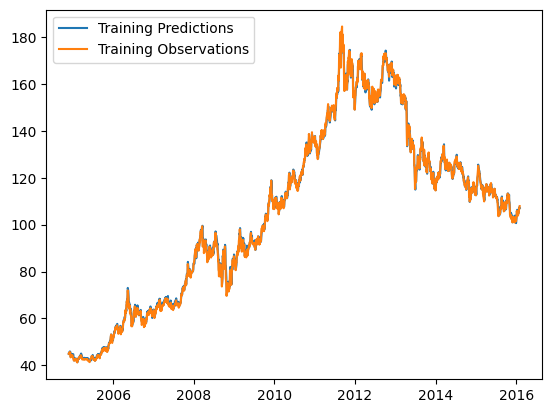

In [20]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
)
import numpy as np


mae = mean_absolute_error(y_train, train_predictions)
mse = mean_squared_error(y_train, train_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_predictions)
mape = mean_absolute_percentage_error(y_train, train_predictions)
explained_var = explained_variance_score(y_train, train_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 0.9983
MSE: 1.9249
RMSE: 1.3874
R² Score: 0.9986
MAPE: 0.0097
Explained Variance: 0.9986


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step


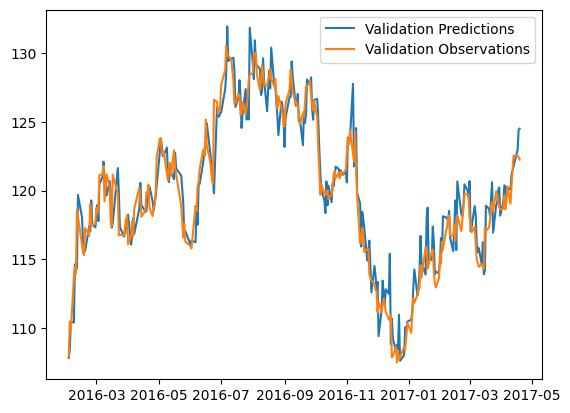

In [22]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

In [23]:
mae = mean_absolute_error(y_val, val_predictions)
mse = mean_squared_error(y_val, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_predictions)
mape = mean_absolute_percentage_error(y_val, val_predictions)
explained_var = explained_variance_score(y_val, val_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1192
MSE: 2.2107
RMSE: 1.4868
R² Score: 0.9253
MAPE: 0.0094
Explained Variance: 0.9268


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


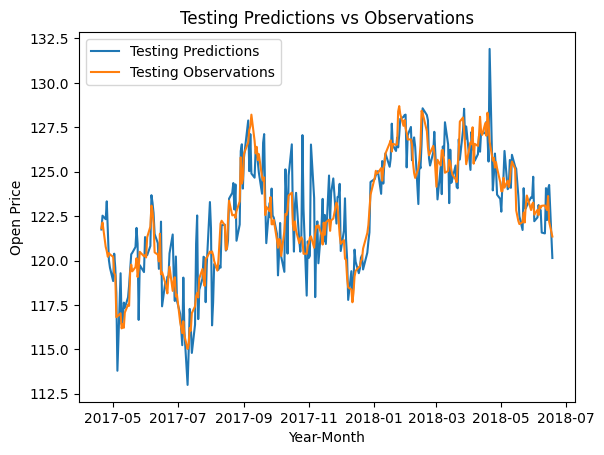

In [ ]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])
plt.xlabel("Year-Month")  # x-axis label
plt.ylabel("Open Price")  # y-axis label
plt.title("Testing Predictions vs Observations")
plt.show()

In [25]:
mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predictions)
mape = mean_absolute_percentage_error(y_test, test_predictions)
explained_var = explained_variance_score(y_test, test_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1270
MSE: 2.1975
RMSE: 1.4824
R² Score: 0.7794
MAPE: 0.0092
Explained Variance: 0.7809


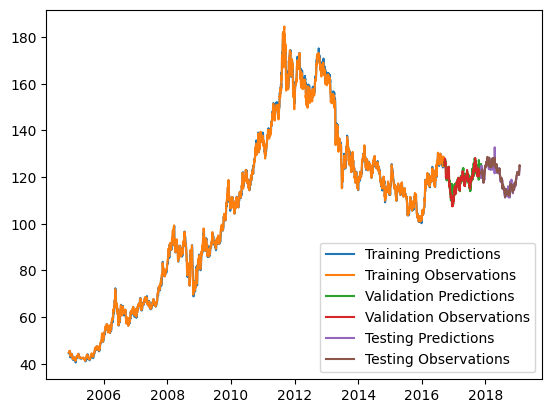

In [31]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
    ]
)

In [32]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━

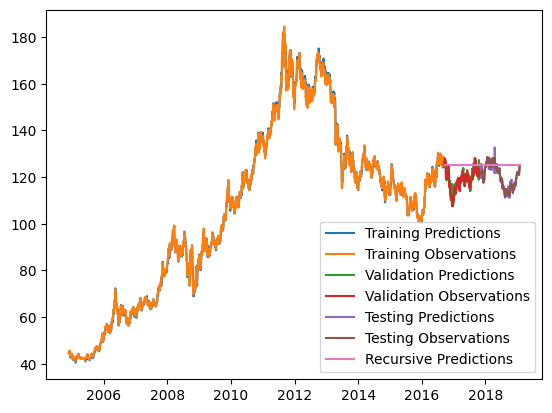

In [33]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(
    [
        "Training Predictions",
        "Training Observations",
        "Validation Predictions",
        "Validation Observations",
        "Testing Predictions",
        "Testing Observations",
        "Recursive Predictions",
    ]
)